# Marta Negri
# Luca Davì

## Taks 2:
assessing the performance of pre-trained models in a zero-shot setting, where no additional training on waste images is performed. This will provide insights
into the generalization capabilities of modern detectors such as YOLO, DETR, and RT-DETR.
After the initial evaluation, fine-tune a small variant of the RT-DETR model on the training split
of the waste images dataset, and assess and discuss its performance, comparing it to the other
models

notes for mac users: We had to switch to colab because of an unimplemented function in the trainer that forced the fall back to cpu, this meant that each training epoch would take 5 minutes, making training impossible

In [1]:
# this works only if you are running in google colab and have the data stored in your google drive
# from google.colab import drive
# import sys
# drive.mount('/content/drive')

# !unzip -oq /content/drive/MyDrive/data.zip -d /content/taco_subset
# sys.path.append('/content/drive/MyDrive/')



In [2]:
!pip install -q gdown
#https://drive.google.com/file/d/1e4tsIf_jCotS91V-5BDJH-gEPphQDydz/view?usp=share_link
#https://drive.google.com/file/d/1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv/view?usp=share_link
FILE_ID = "1e4tsIf_jCotS91V-5BDJH-gEPphQDydz" #dataset
!gdown --id $FILE_ID -O /content/data.zip
FILE_ID = "1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv" #library
!gdown --id $FILE_ID -O /content/taco_dataset.py

!unzip -oq /content/data.zip -d /content/taco_subset



/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1e4tsIf_jCotS91V-5BDJH-gEPphQDydz
From (redirected): https://drive.google.com/uc?id=1e4tsIf_jCotS91V-5BDJH-gEPphQDydz&confirm=t&uuid=dbd45a48-b14b-4232-a508-3a37f63af2bd
To: /content/data.zip
100% 1.12G/1.12G [00:23<00:00, 48.5MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv
From (redirected): https://drive.google.com/uc?id=1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv&confirm=t&uuid=7c012e2d-984e-43eb-86b2-40eadededdcf
To: /content/taco_dataset.py


### 2.1 Dataset Preparation

In [3]:
%pip install pycocotools ultralytics torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.6 MB/s eta 0:00:00


In [4]:
import os

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torchvision
import torch
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:

root = '/content/taco_subset/data/TACO_subset'
train_ann='/content/taco_subset/data/TACO_subset/annotations_train.json'

train_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_train.json', transform=None)
test_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_test.json', transform=None)
val_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_val.json', transform=None)
#yolo and detr require images in different formats with different pipelines

train_dataset[0]

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


(<PIL.Image.Image image mode=RGB size=768x1024>,
 [{'id': 1,
   'image_id': 0,
   'category_id': 2,
   'segmentation': [[280.3175016265452,
     618.6979014153246,
     283.8152244632401,
     600.2069302098585,
     283.31554977228365,
     587.2132747681796,
     274.32140533506833,
     563.2249877989263,
     268.8249837345478,
     544.2342606149341,
     259.33116460637603,
     521.2454856027331,
     258.33181522446324,
     502.25475841874083,
     261.3298633702017,
     481.76476329917034,
     264.3279115159402,
     472.2693997071742,
     259.8308392973325,
     447.78135675939484,
     262.32921275211453,
     430.7896534895071,
     267.825634352635,
     410.29965836993654,
     276.8197787898504,
     384.3123474865788,
     288.3122966818478,
     363.3225963884822,
     297.3064411190631,
     338.8345534407028,
     297.80611581001955,
     292.3572474377745,
     293.80871828236826,
     172.91556857003417,
     290.31099544567337,
     163.91996095656418,
     28

In [6]:
train_length = len(train_dataset)
test_length = len(test_dataset)
val_length = len(val_dataset)
tot_length = train_length + test_length + val_length

print(f"Train dataset length: {train_length}: {train_length/tot_length*100:.2f}% of total")
print(f"Test dataset length: {test_length}: {test_length/tot_length*100:.2f}% of total")
print(f"Validation dataset length: {val_length}: {val_length/tot_length*100:.2f}% of total")

Train dataset length: 799: 69.66% of total
Test dataset length: 178: 15.52% of total
Validation dataset length: 170: 14.82% of total


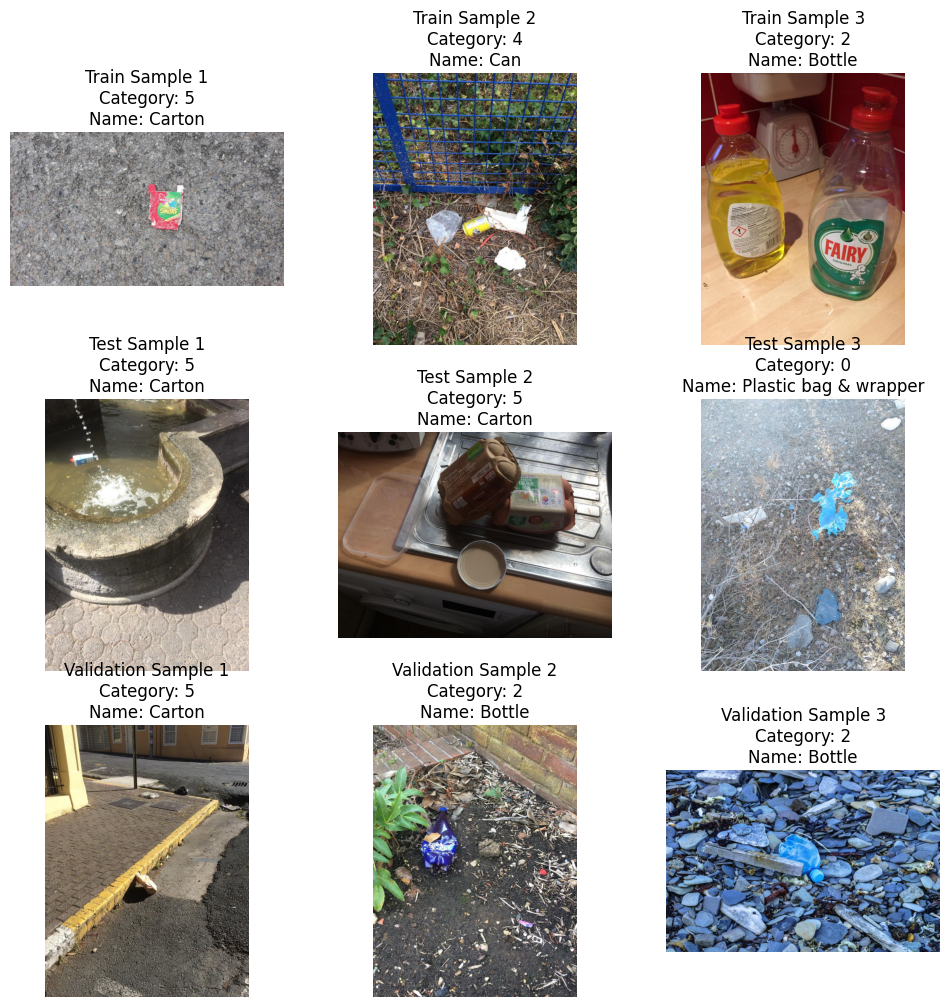

In [7]:
# Visualize three samples from each split with the corresponding category labels with category names

indexes = torch.randint(0, min(train_length, test_length, val_length), (3,)).tolist()

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axs[0, i].imshow(train_dataset[indexes[i]][0])
    axs[0, i].set_title(f"Train Sample {i+1}\nCategory: {train_dataset[indexes[i]][1][0]['category_id']}\nName: {train_dataset.coco.loadCats(train_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[0, i].axis('off')

    axs[1, i].imshow(test_dataset[indexes[i]][0])
    axs[1, i].set_title(f"Test Sample {i+1}\nCategory: {test_dataset[indexes[i]][1][0]['category_id']}\nName: {test_dataset.coco.loadCats(test_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[1, i].axis('off')

    axs[2, i].imshow(val_dataset[indexes[i]][0])
    axs[2, i].set_title(f"Validation Sample {i+1}\nCategory: {val_dataset[indexes[i]][1][0]['category_id']}\nName: {val_dataset.coco.loadCats(val_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[2, i].axis('off')

subtask 2.2. zero-shot detection

In [8]:
#define dataloaders for each split
def collate_fn(batch): #standard collate function for object detection tasks provided in pytorch documentation
    return tuple(zip(*batch))
BATCH_SIZE = 4
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [9]:
#load models

from ultralytics import YOLO
from transformers import pipeline

yolo_model = YOLO('yolo11m.pt').to(device)
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device)
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device)

print(f'Models are on device: \nYOLO: {yolo_model.device}\nDETR device: {detr_model.device}\nRT-DETR device: {rt_detr_model.device}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Device set to use cuda


Models are on device: 
YOLO: cuda:0
DETR device: cuda
RT-DETR device: cuda


In [10]:
def dataset_to_torchmetrics(target):
    #convert coco annotations to torchmetrics format
    boxes = []
    labels = []
    for ann in target:
        box = ann['bbox']
        #coco format is [x_min, y_min, width, height], convert to [x_min, y_min, x_max, y_max]
        box = [box[0], box[1], box[0] + box[2], box[1] + box[3]]
        boxes.append(box)
        labels.append(0) #we don't consider classes, set all to 0
    return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor(labels, dtype=torch.int64)}

def yolo_to_torchmetrics(yolo_results, original_size, IMG_SIZE=640):
    yolo_boxes = yolo_results.boxes.xyxy
    # Rescale boxes to original image size
    yolo_boxes[:, [0, 2]] *= original_size[0] / IMG_SIZE
    yolo_boxes[:, [1, 3]] *= original_size[1] / IMG_SIZE
    return {
        "boxes": yolo_boxes,
        "scores": yolo_results.boxes.conf,
        "labels": torch.zeros(len(yolo_results.boxes.xyxy), dtype=torch.int64), # Ignoring class
    }

def detr_to_torchmetrics(detr_results, confidence_threshold=0.1):
    detr_results = [res for res in detr_results if res['score'] >= confidence_threshold]
    if len(detr_results) == 0:
        return {
            "boxes": torch.empty((0, 4), dtype=torch.float32),
            "scores": torch.empty((0,), dtype=torch.float32),
            "labels": torch.empty((0,), dtype=torch.int64), # Ignoring class
        }
    boxes = []
    scores = []
    for res in detr_results:
        box = res['box']
        if isinstance(box, dict):
            boxes.append([box['xmin'], box['ymin'], box['xmax'], box['ymax']])
        else:
            x,y,w,h = box
            boxes.append([x, y, x + w, y + h])
        scores.append(res['score'])
    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "scores": torch.tensor(scores, dtype=torch.float32),
        "labels": torch.zeros(len(boxes), dtype=torch.int64), # Ignoring class
    }

In [11]:
def yolo_top_IoU(yolo_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP
    top_indexes = torch.argsort(yolo_pred["scores"], descending=True)[:n_boxes]
    selected_boxes = yolo_pred["boxes"][top_indexes]
    selected_scores = yolo_pred["scores"][top_indexes]

    #ensure same device
        # selected_boxes = selected_boxes.to(device)
        # selected_scores = selected_scores.to(device)
        # target_boxes = target['boxes'].to(device)

    ious = torchvision.ops.box_iou(selected_boxes, target["boxes"])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

def detr_top_IoU(detr_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP

    top_indexes = torch.argsort(detr_pred['scores'], descending=True)[:n_boxes]
    selected_boxes = detr_pred['boxes'][top_indexes]
    selected_scores = detr_pred['scores'][top_indexes]

    ious = torchvision.ops.box_iou(selected_boxes, target['boxes'])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

In [12]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
IMG_SIZE = 640
def evaluate_models(yolo_model, detr_model,rt_detr_model, data_loader):

    metric_yolo = MeanAveragePrecision(class_metrics=False)
    metric_detr = MeanAveragePrecision(class_metrics=False)
    metric_rt_detr = MeanAveragePrecision(class_metrics=False)

    iou_metric_yolo = MeanAveragePrecision(class_metrics=False)
    iou_metric_detr = MeanAveragePrecision(class_metrics=False)
    iou_metric_rt_detr = MeanAveragePrecision(class_metrics=False)
    # yolo_confs = []
    # detr_scores = []
    # rt_detr_scores = []
    with torch.no_grad():
        for images, targets in data_loader:
            original_sizes = [img.size for img in images]  # Store original sizes for image rescaling
            yolo_batch = torch.stack(
                [torchvision.transforms.ToTensor()(
                    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE))(img))
                    for img in images]) #YOLO is happier with tensor [B,C,W,H], but doesn't handle resizing internally

            #YOLO inference
            yolo_results = yolo_model(yolo_batch, verbose=False)
            #DETR inference
            detr_batch = [img.convert("RGB") if img.mode != "RGB" else img for img in images] #DETR needs PIL RGB images
            detr_results = detr_model(detr_batch)
            #RT-DETR inference
            rt_detr_results = rt_detr_model(detr_batch)

            #transform target to map format
            targets = [dataset_to_torchmetrics(t) for t in targets]
            #yolo_results are the only one on device instead of cpu, move them
            yolo_results = [res.to('cpu') for res in yolo_results]
            #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            #determine top k predictions for each model, where k is the number of ground truth boxes in the image
            for og_size,target,yolo_res,detr_res,rt_detr_res in zip(original_sizes,targets,yolo_results,detr_results,rt_detr_results):
                k = len(target)
                yolo_sorted_indices = torch.argsort(yolo_res.boxes.conf, descending=True)[:k]
                yolo_topk = yolo_res[yolo_sorted_indices]

                detr_topk = sorted(detr_res, key=lambda x: x['score'], reverse=True)[:k]
                rt_detr_topk = sorted(rt_detr_res, key=lambda x: x['score'], reverse=True)[:k]

                metric_yolo.update([yolo_to_torchmetrics(yolo_topk, og_size, IMG_SIZE)], [target])
                metric_detr.update([detr_to_torchmetrics(detr_topk)], [target])
                metric_rt_detr.update([detr_to_torchmetrics(rt_detr_topk)], [target])

                # print(target['boxes'].device)
                # print(yolo_res.boxes.xyxy.device)
                # print(detr_to_torchmetrics(detr_res)['boxes'].device)

                iou_metric_yolo.update([yolo_top_IoU(yolo_to_torchmetrics(yolo_res, og_size, IMG_SIZE), target, n_boxes=10)], [target])
                iou_metric_detr.update([detr_top_IoU(detr_to_torchmetrics(detr_res), target, n_boxes=10)], [target])
                iou_metric_rt_detr.update([detr_top_IoU(detr_to_torchmetrics(rt_detr_res), target, n_boxes=10)], [target])

    return metric_yolo.compute(), metric_detr.compute(), metric_rt_detr.compute(), iou_metric_yolo.compute(), iou_metric_detr.compute(), iou_metric_rt_detr.compute()


In [13]:
print("Evaluating models on the test dataset...")

yolo_map, detr_map, rt_detr_map, iou_yolo_map, iou_detr_map, iou_rt_detr_map = evaluate_models(yolo_model, detr_model, rt_detr_model, test_loader)
print(f"YOLO mAP: {yolo_map}")
print(f"DETR mAP: {detr_map}")
print(f"RT-DETR mAP: {rt_detr_map}")

print(f"YOLO IoU-based mAP: {iou_yolo_map}")
print(f"DETR IoU-based mAP: {iou_detr_map}")
print(f"RT-DETR IoU-based mAP: {iou_rt_detr_map}")

Evaluating models on the test dataset...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


YOLO mAP: {'map': tensor(0.0571), 'map_50': tensor(0.0652), 'map_75': tensor(0.0627), 'map_small': tensor(0.), 'map_medium': tensor(0.0574), 'map_large': tensor(0.1173), 'mar_1': tensor(0.0949), 'mar_10': tensor(0.1140), 'mar_100': tensor(0.1140), 'mar_small': tensor(0.), 'mar_medium': tensor(0.0903), 'mar_large': tensor(0.2486), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(0, dtype=torch.int32)}
DETR mAP: {'map': tensor(0.0487), 'map_50': tensor(0.0696), 'map_75': tensor(0.0535), 'map_small': tensor(0.0003), 'map_medium': tensor(0.0767), 'map_large': tensor(0.0926), 'mar_1': tensor(0.0998), 'mar_10': tensor(0.1224), 'mar_100': tensor(0.1224), 'mar_small': tensor(0.0014), 'mar_medium': tensor(0.1246), 'mar_large': tensor(0.2405), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(0, dtype=torch.int32)}
RT-DETR mAP: {'map': tensor(0.0600), 'map_50': tensor(0.0699), 'map_75': tensor(0.0651), 'map_small': tensor(0.0026), 

## Task 2.3. finetuning detr

In [14]:
from transformers import AutoImageProcessor
IMG_SIZE = 480
checkpoint = "PekingU/rtdetr_v2_r50vd"


label2id = {'Plastic bag & wrapper': 0,
  'Cigarette': 1,
  'Bottle': 2,
  'Bottle cap': 3,
  'Can': 4,
  'Carton': 5}

id2label = {v: k for k, v in label2id.items()}
label2id, id2label
categories = list(id2label.values())

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"height": IMG_SIZE, "width": IMG_SIZE},
    use_fast=True,
)


preprocessor_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

In [15]:
import albumentations as A

train_augmentation_and_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True,
                            min_area=25,        # Discard boxes smaller than 5x5 pixels
                            min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

validation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"],
                             clip=True,
                             min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

In [16]:
#load datasets with provided custom dataset class

from taco_dataset import TACODETRDetectionDataset


train_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_train.json',processor=image_processor, transform=train_augmentation_and_transform)
test_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_test.json',processor=image_processor, transform= validation_transform)
val_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_val.json',processor=image_processor, transform=validation_transform)

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (4, 4)
Categories shape: (4,)


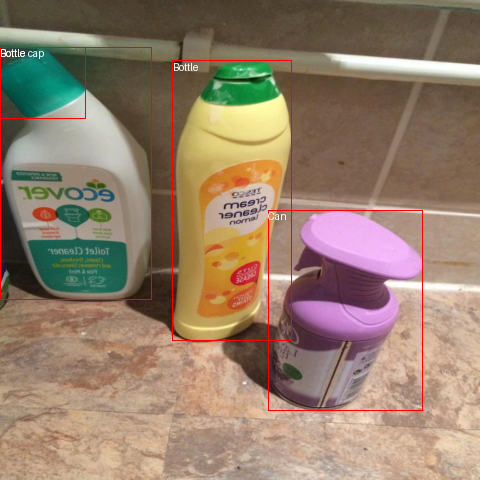

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


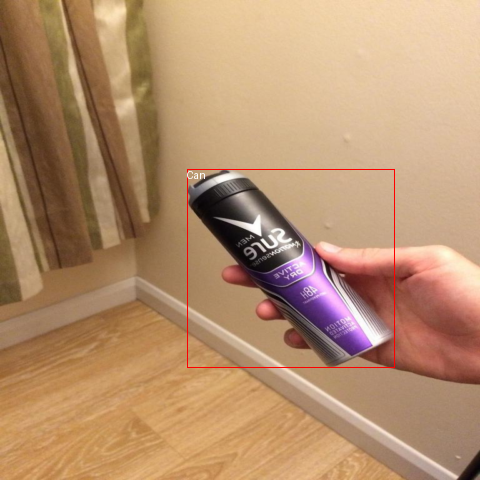

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


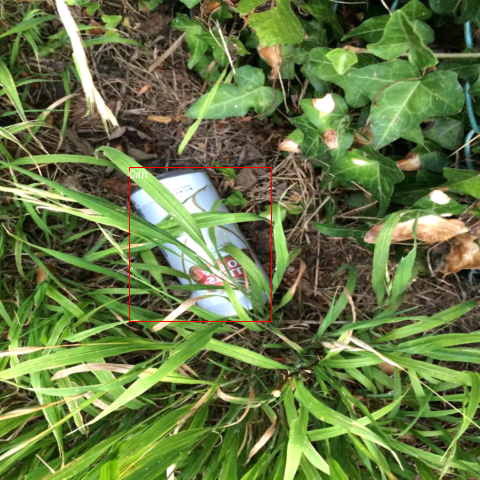

In [17]:
from PIL import Image, ImageDraw
for i in [15, 16, 17]:
    sample = train_dataset[i]

    # De-normalize image
    image = sample["pixel_values"]
    print("Image tensor shape:", image.shape)
    image = image.numpy().transpose(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min()) * 255.
    image = Image.fromarray(image.astype(np.uint8))

    # Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
    boxes = sample["labels"]["boxes"].numpy()
    print("Boxes shape:", boxes.shape)
    boxes[:, :2] = boxes[:, :2] - boxes[:, 2:] / 2
    w, h = image.size
    boxes = boxes * np.array([w, h, w, h])[None]

    categories = sample["labels"]["class_labels"].numpy()
    print("Categories shape:", categories.shape)

    # Draw boxes and labels on image
    draw = ImageDraw.Draw(image)
    for box, category in zip(boxes, categories):
        x, y, w, h = box
        draw.rectangle([x, y, x + w, y + h], outline="red", width=1)
        draw.text((x, y), id2label[category], fill="white")

    display(image)

In [18]:
from dataclasses import dataclass
from transformers.image_transforms import center_to_corners_format

@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label
    def collect_image_sizes(self,targets):
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x['size'] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes
    def collect_targets(self, targets, image_sizes):
        post_processed_targets=[]
        for target_batch, image_size_batch in zip(targets, image_sizes):
            batch_targets = []
            for target, size in zip(target_batch, image_size_batch):
                height, width = size
                boxes = torch.tensor(target['boxes'])
                boxes = center_to_corners_format(boxes)
                boxes = boxes * torch.tensor([width, height, width, height], dtype=torch.float32)

                labels = torch.tensor(target['class_labels'])
                post_processed_targets.append({'boxes': boxes, 'labels': labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")

        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = self.id2label[class_id.item()] if self.id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
        return metrics


eval_compute_metrics_fn = MAPEvaluator(image_processor=image_processor, threshold=0.1, id2label=None)

In [19]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label= id2label,
    label2id= label2id,
    num_labels=len(id2label),
    ignore_mismatched_sizes=True,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decod

In [20]:
from taco_dataset import taco_detr_collate_fn
collate_fn = taco_detr_collate_fn

In [21]:
#if you don't have / want to use wandb account, set it to offline mode
#    os.environ['WANDB_MODE']= 'offline'

from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir=f"{checkpoint}-finetuned-taco",
    num_train_epochs=2,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=8,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    logging_strategy="steps",
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="wandb",
    fp16 = True #for colab T4 instance
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,
    data_collator = collate_fn,
    compute_metrics = eval_compute_metrics_fn,
)


In [22]:
#wandb setup, comment this if you don't want to use wandb
import wandb
run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: luca-davi (luca-davi-universit-di-bologna) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [23]:
trainer.train()
run.finish()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map 0,Mar 100 0,Map 1,Mar 100 1,Map 2,Mar 100 2,Map 3,Mar 100 3,Map 4,Mar 100 4,Map 5,Mar 100 5
1,71.549400,43.497833,0.010000,0.013300,0.010900,0.000800,0.011900,0.028600,0.055700,0.144500,0.231000,0.067500,0.255300,0.609100,0.017800,0.260000,0.000100,0.046800,0.006500,0.355700,0.000400,0.243200,0.031600,0.210600,0.003400,0.269400
2,33.372600,20.286095,0.140200,0.173300,0.152700,0.085100,0.147900,0.466200,0.278000,0.442700,0.493500,0.312000,0.541100,0.848300,0.168300,0.472000,0.000500,0.069400,0.153000,0.601400,0.065600,0.483800,0.363300,0.731900,0.090300,0.602800


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.wei

eval/loss,█▁
eval/map,▁█
eval/map_0,▁█
eval/map_1,▁█
eval/map_2,▁█
eval/map_3,▁█
eval/map_4,▁█
eval/map_5,▁█
eval/map_50,▁█
eval/map_75,▁█
+23,...


In [24]:



run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO",id=run.id, resume="allow")

# Folder where Trainer stored the best model
best_dir = "rt_detr_taco_best"

# 1. Save best model weights + processor to a folder
trainer.model.save_pretrained(best_dir)
image_processor.save_pretrained(best_dir)

# 2. Create artifact
artifact = wandb.Artifact(
    name="rtdetr_taco_best",
    type="model",
    description="Best RT-DETR model selected by eval_map",
)

# 3. Add the entire folder to the artifact
artifact.add_dir(best_dir)

# 4. Log artifact to W&B
run.log_artifact(artifact)

# 5. Optional: wait until upload finishes
artifact.wait()

run.finish()


wandb: Adding directory to artifact (rt_detr_taco_best)... Done. 6.4s


eval/loss,20.28609
eval/map,0.1402
eval/map_0,0.1683
eval/map_1,0.0005
eval/map_2,0.153
eval/map_3,0.0656
eval/map_4,0.3633
eval/map_5,0.0903
eval/map_50,0.1733
eval/map_75,0.1527
+28,...


['train/epoch', 'eval/map_4', 'eval/map_50', 'eval/mar_100_5', 'eval/map_medium', 'eval/map_1', 'eval/samples_per_second', 'eval/loss', 'eval/map_0', 'eval/map_3', 'train/grad_norm', '_timestamp', 'eval/mar_100_0', 'eval/map_75', 'train/loss', 'eval/map_small', 'eval/steps_per_second', 'eval/mar_100_1', 'eval/mar_large', 'eval/map_5', 'train/learning_rate', '_step', 'eval/mar_small', 'eval/mar_10', 'eval/mar_100', 'eval/mar_100_2', 'eval/mar_medium', 'eval/map_large', 'train/global_step', '_runtime', 'eval/mar_1', 'eval/mar_100_3', 'eval/map', 'eval/map_2', 'eval/runtime', 'eval/mar_100_4']


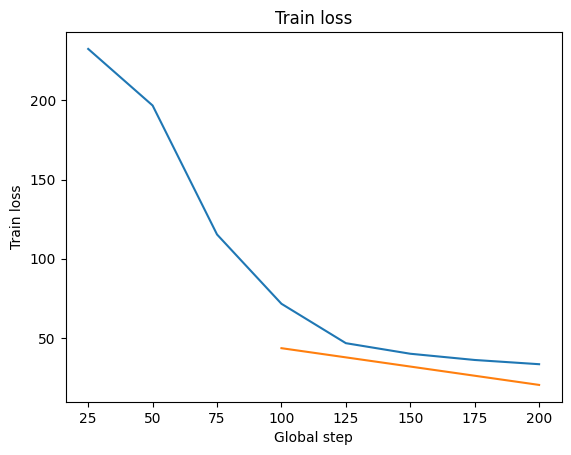

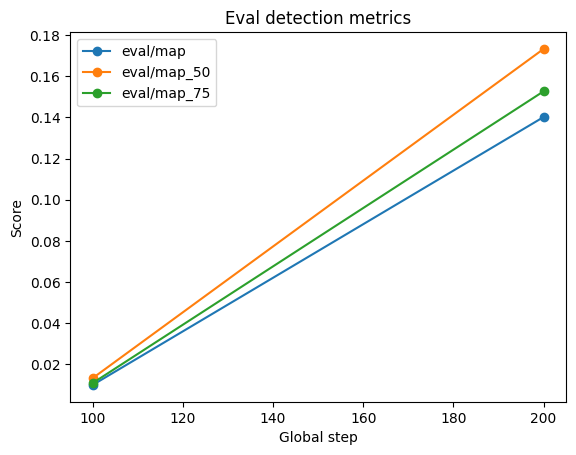

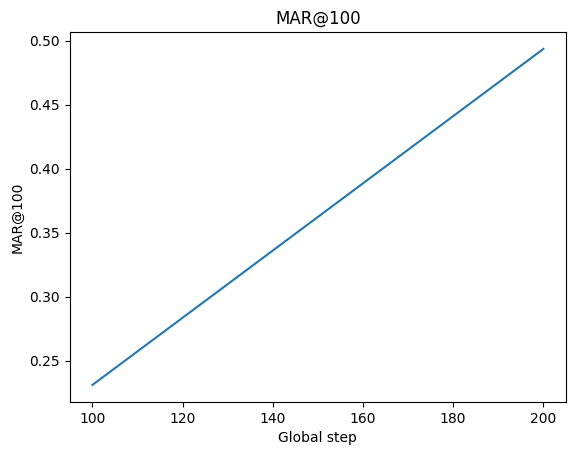

In [27]:
api = wandb.Api()


results = api.run(f"VisComp2025-Assignment2/runs/{run.id}").history(samples=None)
print(results.columns.tolist())

import matplotlib.pyplot as plt

step_col = "train/global_step"  # or "_step", both exist
train_col = "train/loss"
eval_col = "eval/loss"

train_hist = results[[step_col, train_col]].dropna()
eval_hist = results[[step_col, eval_col]].dropna()

plt.figure()
plt.plot(train_hist[step_col], train_hist[train_col])
plt.plot(eval_hist[step_col], eval_hist[eval_col])
plt.xlabel("Global step")
plt.ylabel("Train loss")
plt.title("Train loss")
plt.show()

metrics = ["eval/map", "eval/map_50", "eval/map_75"]

plt.figure()
for m in metrics:
    sub = results[[step_col, m]].dropna()
    plt.plot(sub[step_col], sub[m], marker="o", label=m)

plt.xlabel("Global step")
plt.ylabel("Score")
plt.title("Eval detection metrics")
plt.legend()
plt.show()

train_hist = results[[step_col,"eval/mar_100"]].dropna()
plt.figure()
plt.plot(train_hist[step_col], train_hist["eval/mar_100"])
plt.xlabel("Global step")
plt.ylabel("MAR@100")
plt.title("MAR@100")
plt.show()


In [34]:
#obtain epoch that generated best model

metric_col = "eval/map"
step_col = "_step"
idx = results[metric_col].idxmax()

row = results.loc[idx]

print("Best eval_map:", row[metric_col])
print("At epoch:", row.get("train/epoch"))
print("At step:", row.get("_step") or row.get("train/global_step"))
row

Best eval_map: 0.1402
At epoch: 2.0
At step: 9.0


,9
train/epoch,2.000000e+00
eval/map_4,3.633000e-01
eval/map_50,1.733000e-01
eval/mar_100_5,6.028000e-01
eval/map_medium,1.479000e-01
eval/map_1,5.000000e-04
eval/samples_per_second,1.850300e+01
eval/loss,2.028609e+01
eval/map_0,1.683000e-01
eval/map_3,6.560000e-02


inference on a single image

Detected Can with confidence 0.415 at location [197.78, 230.69, 352.97, 319.69]
Detected Bottle with confidence 0.339 at location [197.49, 230.41, 352.81, 319.1]
Detected Cigarette with confidence 0.311 at location [408.9, 428.08, 418.83, 435.93]


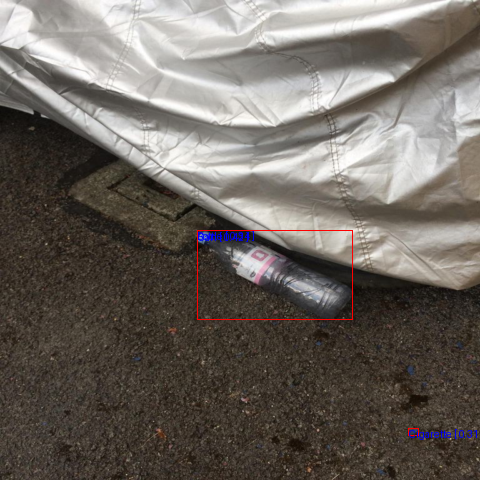

In [26]:

image_index = 2

# The model always expects a batch, so we need to collate our single sample into a batch
inputs = taco_detr_collate_fn([train_dataset[image_index]])
inputs = {k: ( v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

inputs.pop("labels")  # Remove labels for inference
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([(IMG_SIZE, IMG_SIZE)])

result = image_processor.post_process_object_detection(outputs,
                                                       threshold=0.3, # Confidence threshold
                                                       target_sizes=target_sizes)[0]

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

image = inputs["pixel_values"][0].detach().cpu()
image_with_boxes = image.numpy().transpose(1, 2, 0)
image_with_boxes = (image_with_boxes - image_with_boxes.min()) / (image_with_boxes.max() - image_with_boxes.min()) * 255.
image_with_boxes = Image.fromarray(image_with_boxes.astype(np.uint8))

draw = ImageDraw.Draw(image_with_boxes)

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    draw.rectangle((x, y, x2, y2), outline="red", width=1)
    text_label = model.config.id2label[label.item()]
    draw.text((x, y), f"{text_label} [ {score.item():.2f} ]", fill="blue")

image_with_boxes